In [1]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [2]:
load("/vol/projects/yzhang/500FG_aging/output/01_cytokine/cytokine_prediction.Rdata")

In [5]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
head(basicPhenos)
#basicPhenos <- basicPhenos[!is.na(basicPhenos$Age), ] None missing value
dim(basicPhenos)

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
6,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 527  18

In [10]:
cytokine <-  read.csv("/vol/projects/yzhang/500FG_aging/input/cytokine/cytokine_rank_normalized.csv",row.names=1)
head(cytokine)
dim(cytokine)
sum(is.na(cytokine))

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,1.605497067,1.34720533,0.7319277,1.24068016,0.7658547,2.1110871,0.2169839,1.09850591,0.2644787,0.80068698,⋯,0.09754904,-0.29647001,-0.6793241,0.2433026,-0.4167085,-0.8659765,-0.7252435,-0.1027008,-1.7288018,-0.967421566
HV002,0.666467274,0.24858607,1.0351187,0.88857203,0.9839230,1.0177570,0.4167085,-0.09754904,1.2081388,0.41670853,⋯,0.14920662,0.84381462,1.0006968,1.8564132,0.4055523,-2.7404790,0.2485861,0.8148941,-0.2591740,-3.083619477
HV003,0.005126052,1.44206423,-0.8292677,0.37237797,0.2751108,1.5693585,-0.5793216,0.09754904,-0.5492672,0.03076103,⋯,0.22749237,1.42771387,-0.5552377,1.0177570,0.1803845,-0.3504895,0.6922943,1.2745912,0.9038911,0.752180131
HV004,-1.587168718,-1.80181420,-1.3472053,-1.25182415,-0.3504895,0.2433026,1.7521117,-0.01537869,0.7319277,0.95117944,⋯,-0.06668778,1.38633652,-0.7727459,0.1751768,0.3125781,-0.1647755,-0.3723780,0.1647755,0.1388476,0.005126052
HV005,0.372377973,0.01025224,-0.9592689,-0.08725308,-0.3723780,0.4335412,-0.5853949,0.22223509,-0.1855971,0.10270084,⋯,0.03076103,0.01025224,-1.0985059,-1.0708129,-0.5080020,-1.2406802,-1.8018142,-0.8006870,-0.7453954,-0.880990229
HV006,0.248586074,-0.62230348,-0.8885720,-0.07696636,-1.0527981,-1.0006968,-1.6438630,-0.47331029,-0.7796739,-0.85115541,⋯,-0.08725308,0.51384271,-1.0527981,-0.2433026,0.1699739,-0.2857741,-0.4905823,-0.7386448,-0.2697910,-0.622303483


[1] 489  91

[1] 0

In [3]:
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(cytokine), basicPhenos$ID_500fg) 
length(idx) #458samples
cytokine_filter = cytokine[which(rownames(cytokine) %in% idx),]
head(cytokine_filter)  #458samples,1596 metabolite
dim(cytokine_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(cytokine_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(cytokine_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(cytokine))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
# write.csv(cytokine_filter, file = "/vol/projects/yzhang/500FG_aging/input/cytokine/common_cytokine_filter_age.csv")
# write.csv(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/input/cytokine/common_basicPhenos_filter_match_cytokine_age.csv")

[1] 482

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,10.828930,10.710806,8.965784,10.366322,11.34541,10.595257,8.392317,10.051209,13.26033,13.03480,⋯,9.186981,8.290019,8.335390,7.936638,8.005625,10.152285,7.459432,8.326429,6.285402,9.417853
HV002,9.457381,8.761551,9.511753,9.651052,11.43359,9.652845,8.558421,9.162391,13.74431,12.81238,⋯,9.272279,10.594325,10.156083,9.703904,9.142107,4.954196,8.927778,9.579316,7.149747,6.285402
HV003,8.413628,10.884934,5.857981,8.442943,11.03480,10.098032,7.475733,9.321928,12.89045,12.62708,⋯,9.415627,11.640697,8.467606,8.857981,8.927778,10.637531,9.592457,10.224002,8.654636,11.734710
HV004,5.643856,5.285402,5.285402,5.426265,10.69697,8.894818,10.008429,9.238405,13.48533,13.11586,⋯,8.873512,11.611486,8.224002,7.851749,9.079485,10.795228,8.129283,8.654636,7.781360,10.781360
HV005,8.957102,8.179909,5.700440,7.459432,10.68299,9.105909,7.475733,9.396605,13.04405,12.66977,⋯,9.071279,9.071279,7.845490,6.149747,7.864186,9.829723,6.285402,7.149747,6.507795,9.529431
HV006,8.774787,6.727920,5.781360,7.483816,10.22641,7.599913,6.266787,8.761551,12.75572,12.06205,⋯,8.841234,10.087463,7.876517,7.303781,8.921841,10.710806,7.930737,7.375039,7.149747,9.946906


[1] 482  91

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
6,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1


[1] 482  18

[1] 2

Warning message in basicPhenos_filter_match$ID_500fg == rownames(cytokine):
“longer object length is not a multiple of shorter object length”


[1] 201

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
373,304,HV001,male,27,178,70,22.09317,Married,University degree,European,Once a month,Yes,No,24,7,204,2013,Group 5
355,305,HV002,male,26,178,68,21.46194,Cohabitation,University degree,European,Rarely,No,Yes,24,7,204,2013,Group 4
283,257,HV003,female,24,173,68,22.72044,Married,University degree,European,Rarely,Yes,Yes,26,8,236,2013,Group 4
90,258,HV004,female,20,173,65,21.71807,Married,University degree,European,Rarely,Yes,No,26,8,236,2013,Group 2
195,254,HV005,female,22,178,64,20.19947,Married,University student,European,Once a month,Yes,Yes,5,9,245,2013,Group 3
306,530,HV006,female,24,168,58,20.54989,Married,University degree,European,Rarely,Yes,No,NA,NA,NA,NA,Group 4


[1] 482  18

In [4]:
cytokine_age <- cbind(cytokine_filter, Age = basicPhenos_filter_match$Age)
head(cytokine_age)
dim(cytokine_age)

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV001,10.828930,10.710806,8.965784,10.366322,11.34541,10.595257,8.392317,10.051209,13.26033,13.03480,⋯,8.290019,8.335390,7.936638,8.005625,10.152285,7.459432,8.326429,6.285402,9.417853,27
HV002,9.457381,8.761551,9.511753,9.651052,11.43359,9.652845,8.558421,9.162391,13.74431,12.81238,⋯,10.594325,10.156083,9.703904,9.142107,4.954196,8.927778,9.579316,7.149747,6.285402,26
HV003,8.413628,10.884934,5.857981,8.442943,11.03480,10.098032,7.475733,9.321928,12.89045,12.62708,⋯,11.640697,8.467606,8.857981,8.927778,10.637531,9.592457,10.224002,8.654636,11.734710,24
HV004,5.643856,5.285402,5.285402,5.426265,10.69697,8.894818,10.008429,9.238405,13.48533,13.11586,⋯,11.611486,8.224002,7.851749,9.079485,10.795228,8.129283,8.654636,7.781360,10.781360,20
HV005,8.957102,8.179909,5.700440,7.459432,10.68299,9.105909,7.475733,9.396605,13.04405,12.66977,⋯,9.071279,7.845490,6.149747,7.864186,9.829723,6.285402,7.149747,6.507795,9.529431,22
HV006,8.774787,6.727920,5.781360,7.483816,10.22641,7.599913,6.266787,8.761551,12.75572,12.06205,⋯,10.087463,7.876517,7.303781,8.921841,10.710806,7.930737,7.375039,7.149747,9.946906,24


[1] 482  92

In [5]:
##perform 100 times
# Custom function to train and evaluate the model
train_and_evaluate <- function(data, seed, iteration) {
  set.seed(seed)
  
  # Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
  
  # Set up the grid for hyperparameter tuning
  # netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))    
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
  # Train the model
  netFit <- train(Age ~ ., data = training, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training)
  val_predictions <- predict(netFit, newdata = validation)
  
    # Save predicted age for each sample   
   pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training),
      Age_true = training$Age,
      Age_pred = as.numeric(train_predictions),
      stringsAsFactors = FALSE
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation),
      Age_true = validation$Age,
      Age_pred = as.numeric(val_predictions),
      stringsAsFactors = FALSE
    )
  )
  # Compute performance metrics for training set
  train_rmse <- sqrt(mean((training$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training$Age, train_predictions)^2       # R²
  
  # Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation$Age, val_predictions)^2         # R²
  
  # Return metrics
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    best_model = netFit,
    # selected_features = selected_features,
    predictions = pred_df
  )
}

In [6]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(cytokine_age, seed = i, iteration = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)

# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values)),
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values))
)

# Print summary
head(metrics_summary)

,Metric,Mean,SD
,<chr>,<dbl>,<dbl>
1,Train RMSE,10.9775728,0.46883229
2,Validation RMSE,11.8820609,0.81059723
3,Train MSE,120.7247092,10.13869193
4,Validation MSE,141.8338696,19.27361909
5,Train R²,0.2354109,0.05804199
6,Validation R²,0.1219982,0.03407473


In [7]:
saveRDS(results, "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/cytokine_prediction_elastic_results.rds")

all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet_orign_sample_feature/cytokine_pre_age_elasticnet_orign_sample_feature.csv", row.names = FALSE)

null device 
          1

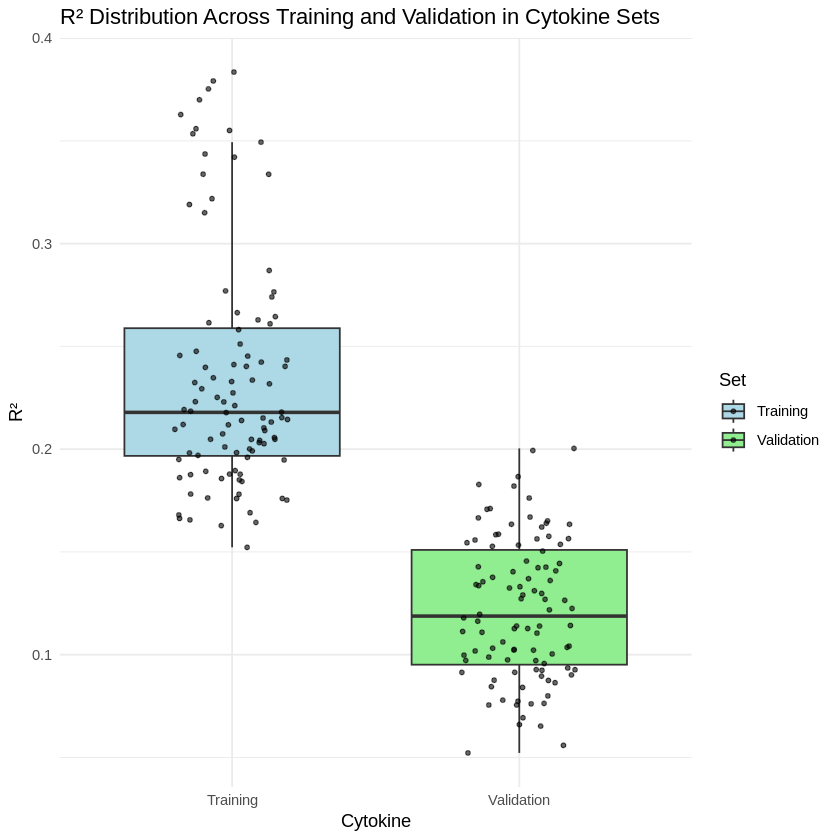

In [8]:
# Combine R² metrics into a single data frame for plotting
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)

# Plot only R²
ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/01_cytokine/cytokine_cross_validation.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Cytokine Sets",
       x = "Cytokine",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))

print(g)
dev.off()
print(g)

In [9]:
save.image("/vol/projects/yzhang/500FG_aging/output/01_cytokine/cytokine_prediction_elastic_orig_sample_feature.Rdata")